# Vascular skin lesions with Ray AI Runtime (AIR)

## Notebook overview

This notebook builds a vascular lesion classifier using Ray AIR:
- Ray Data for parallel image loading and feature extraction.
- Ray Train for SVM training in a reproducible pipeline.
- Ray Tune for lightweight hyperparameter search.

The dataset is small, so image size and tuning budget are kept modest.

In [24]:
# Imports and configuration
from pathlib import Path
import os
import pickle
import tempfile
import numpy as np
import pandas as pd
from PIL import Image, ImageFilter
import matplotlib.pyplot as plt

import ray
import ray.train as train
from ray.train import Checkpoint
from ray.air.config import ScalingConfig, RunConfig
from ray import tune
from ray.tune.tuner import Tuner, TuneConfig

from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
 )
from sklearn.preprocessing import StandardScaler as SkStandardScaler

%matplotlib inline

RANDOM_STATE = 42
DATA_DIR = Path("vascular_skin_lesion")
IMG_SIZE = (96, 96)

In [25]:
# Start Ray runtime
if ray.is_initialized():
    ray.shutdown()

ray.init(object_store_memory=1.5 * 1024 * 1024 * 1024)

2026-05-27 00:41:22,502	INFO worker.py:2012 -- Started a local Ray instance.


Python version:,3.13.7
Ray version:,2.55.1


In [26]:
# Build an index of image paths and labels
records = []
for cls_dir in sorted([p for p in DATA_DIR.iterdir() if p.is_dir()]):
    cls = cls_dir.name
    for img_path in cls_dir.glob("*"):
        records.append({"path": str(img_path), "label": cls})

if not records:
    raise ValueError(f"No images found under {DATA_DIR.resolve()}")

label_names = sorted({r["label"] for r in records})
label_to_id = {name: idx for idx, name in enumerate(label_names)}

for r in records:
    r["label"] = label_to_id[r["label"]]

img_ds = ray.data.from_items(records).random_shuffle(seed=RANDOM_STATE)

print("Total images:", len(records))
print("Class map:", label_to_id)

Total images: 284
Class map: {'nv': 0, 'vasc': 1}


Class counts:
label
0    142
1    142
Name: count, dtype: int64


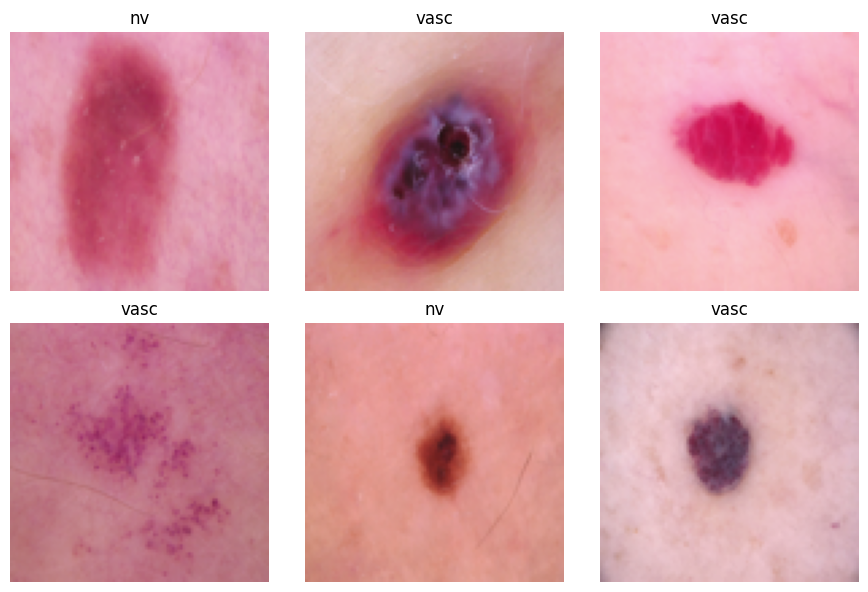

In [27]:
# Quick dataset analysis and samples
df = pd.DataFrame(records)
print("Class counts:")
print(df["label"].value_counts().sort_index())

sample = df.sample(min(6, len(df)), random_state=RANDOM_STATE)
cols = 3
rows = int(np.ceil(len(sample) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for ax in axes[len(sample):]:
    ax.axis("off")

for i, (_, r) in enumerate(sample.iterrows()):
    img = Image.open(r["path"]).convert("RGB")
    ax = axes[i]
    ax.imshow(img.resize(IMG_SIZE))
    ax.set_title(label_names[int(r["label"])])
    ax.axis("off")

plt.tight_layout()

In [28]:
# Preprocessing helpers
def gray_world_balance(img):
    means = img.reshape(-1, 3).mean(axis=0)
    mean_all = means.mean()
    scale = mean_all / (means + 1e-8)
    balanced = img * scale
    return np.clip(balanced, 0.0, 1.0)

def contrast_stretch(img, lo=1, hi=99):
    out = img.copy()
    for c in range(3):
        p_lo, p_hi = np.percentile(out[..., c], [lo, hi])
        if p_hi - p_lo < 1e-6:
            continue
        out[..., c] = (out[..., c] - p_lo) / (p_hi - p_lo)
    return np.clip(out, 0.0, 1.0)

def otsu_threshold(gray):
    hist, _ = np.histogram(gray.ravel(), bins=256, range=(0.0, 1.0))
    hist = hist.astype(np.float64)
    prob = hist / (hist.sum() + 1e-12)
    omega = np.cumsum(prob)
    mu = np.cumsum(prob * np.linspace(0.0, 1.0, 256))
    mu_t = mu[-1]
    sigma_b = (mu_t * omega - mu) ** 2 / (omega * (1.0 - omega) + 1e-12)
    idx = np.nanargmax(sigma_b)
    return idx / 255.0

def binary_erode(mask):
    mask = mask.astype(np.uint8)
    padded = np.pad(mask, 1, mode="constant", constant_values=0)
    eroded = np.ones_like(mask, dtype=np.uint8)
    h, w = mask.shape
    for dy in (-1, 0, 1):
        for dx in (-1, 0, 1):
            eroded = np.minimum(eroded, padded[1 + dy : 1 + dy + h, 1 + dx : 1 + dx + w])
    return eroded.astype(bool)

def binary_dilate(mask):
    mask = mask.astype(np.uint8)
    padded = np.pad(mask, 1, mode="constant", constant_values=0)
    dilated = np.zeros_like(mask, dtype=np.uint8)
    h, w = mask.shape
    for dy in (-1, 0, 1):
        for dx in (-1, 0, 1):
            dilated = np.maximum(dilated, padded[1 + dy : 1 + dy + h, 1 + dx : 1 + dx + w])
    return dilated.astype(bool)

def clean_mask(mask):
    mask = binary_dilate(binary_erode(mask))
    mask = binary_erode(binary_dilate(mask))
    return mask

def preprocess_image(path, size=IMG_SIZE):
    with Image.open(path) as im:
        im = im.convert("RGB")
        im = im.filter(ImageFilter.MedianFilter(size=3))
        im = im.resize(size)
        img = np.array(im).astype(np.float32) / 255.0
    img = gray_world_balance(img)
    img = contrast_stretch(img)
    gray = img.mean(axis=2)
    thresh = otsu_threshold(gray)
    mask = gray < thresh
    if mask.mean() > 0.6:
        mask = ~mask
    mask = clean_mask(mask)
    img_seg = img * mask[..., None]
    return img, img_seg, mask

## Preprocessing and segmentation
We apply a light artifact reduction and color normalization pipeline, then create a coarse lesion mask using Otsu thresholding on the corrected grayscale image.

Pipeline:
- Median filter to suppress thin hair-like artifacts.
- Gray-world color constancy and percentile contrast stretch.
- Otsu threshold on grayscale, with simple morphology to clean the mask.

In [29]:
# Feature extraction helpers
def hsv_hist_features(img, bins=(16, 8, 8)):
    hsv = Image.fromarray((img * 255).astype(np.uint8)).convert("HSV")
    hsv = np.array(hsv).astype(np.float32)
    h = hsv[..., 0]
    s = hsv[..., 1]
    v = hsv[..., 2]
    h_hist = np.histogram(h, bins=bins[0], range=(0, 255), density=True)[0]
    s_hist = np.histogram(s, bins=bins[1], range=(0, 255), density=True)[0]
    v_hist = np.histogram(v, bins=bins[2], range=(0, 255), density=True)[0]
    return np.concatenate([h_hist, s_hist, v_hist])

def lbp_hist(gray):
    g = (gray * 255).astype(np.uint8)
    center = g[1:-1, 1:-1]
    lbp = np.zeros_like(center, dtype=np.uint8)
    lbp |= ((g[1:-1, 2:] >= center).astype(np.uint8) << 0)
    lbp |= ((g[:-2, 2:] >= center).astype(np.uint8) << 1)
    lbp |= ((g[:-2, 1:-1] >= center).astype(np.uint8) << 2)
    lbp |= ((g[:-2, :-2] >= center).astype(np.uint8) << 3)
    lbp |= ((g[1:-1, :-2] >= center).astype(np.uint8) << 4)
    lbp |= ((g[2:, :-2] >= center).astype(np.uint8) << 5)
    lbp |= ((g[2:, 1:-1] >= center).astype(np.uint8) << 6)
    lbp |= ((g[2:, 2:] >= center).astype(np.uint8) << 7)
    hist = np.histogram(lbp.ravel(), bins=256, range=(0, 256), density=True)[0]
    return hist

def shape_features(mask):
    if mask.sum() == 0:
        return np.zeros(6, dtype=np.float32)
    ys, xs = np.where(mask)
    area = float(mask.sum())
    boundary = mask & ~binary_erode(mask)
    perimeter = float(boundary.sum())
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    bbox_area = float((y1 - y0 + 1) * (x1 - x0 + 1))
    aspect = (x1 - x0 + 1) / (y1 - y0 + 1)
    extent = area / bbox_area
    ys_c = ys - ys.mean()
    xs_c = xs - xs.mean()
    cov = np.cov(np.vstack([ys_c, xs_c]))
    eig = np.sort(np.linalg.eigvals(cov))
    ecc = 0.0
    if eig[1] > 0:
        ecc = float(np.sqrt(1.0 - eig[0] / eig[1]))
    compact = (perimeter ** 2) / (area + 1e-8)
    return np.array([area, perimeter, aspect, extent, compact, ecc], dtype=np.float32)

def intensity_features(gray, mask):
    if mask.sum() == 0:
        return np.zeros(2, dtype=np.float32)
    vals = gray[mask]
    return np.array([vals.mean(), vals.std()], dtype=np.float32)

def extract_features(path, size=IMG_SIZE):
    img, img_seg, mask = preprocess_image(path, size=size)
    gray = img_seg.mean(axis=2)
    feats = [
        hsv_hist_features(img_seg),
        lbp_hist(gray),
        shape_features(mask),
        intensity_features(gray, mask),
    ]
    return np.concatenate(feats)

feat_example = extract_features(records[0]["path"])
FEATURE_LEN = int(feat_example.shape[0])
FEATURE_COLUMNS = [f"f{i}" for i in range(FEATURE_LEN)]
print("Feature length:", FEATURE_LEN)

Feature length: 296


## Ray Data: featurize the dataset
We use Ray Data to parallelize feature extraction across images and produce a tabular dataset with one row per image.

In [30]:
# Featurize with Ray Data
def featurize_item(item):
    try:
        feat = extract_features(item["path"])
    except Exception:
        return None
    row = {"label": item["label"]}
    for i, val in enumerate(feat):
        row[f"f{i}"] = float(val)
    return row

feat_ds = img_ds.map(featurize_item).filter(lambda x: x is not None)
feat_ds = feat_ds.repartition(num_blocks=4)

train_ds, test_and_val_ds = feat_ds.train_test_split(test_size=0.30, seed=RANDOM_STATE)
val_ds, test_ds = test_and_val_ds.train_test_split(test_size=0.50, seed=RANDOM_STATE)

print("Train/val/test:", train_ds.count(), val_ds.count(), test_ds.count())

/home/wiktor/university/sem6/distributed_systems/skin_cancer/.venv/lib/python3.13/site-packages/ray/data/dataset.py:1633: UserWarning: Use 'expr' instead of 'fn' when possible for performant filters.
  warnings.warn(
2026-05-27 00:41:24,691	INFO logging.py:416 -- Registered dataset logger for dataset dataset_5_0
2026-05-27 00:41:24,694	INFO streaming_executor.py:166 -- Starting execution of Dataset dataset_5_0. Full logs are in /tmp/ray/session_2026-05-27_00-41-20_361029_201857/logs/ray-data
2026-05-27 00:41:24,694	INFO streaming_executor.py:167 -- Execution plan of Dataset dataset_5_0: InputDataBuffer[Input] -> AllToAllOperator[RandomShuffle] -> TaskPoolMapOperator[Map(featurize_item)->Filter(<lambda>)] -> AllToAllOperator[Repartition]
2026-05-27 00:41:25,252	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_5_0 =======
2026-05-27 00:41:25,253	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-05-27 00:41:25,253	INFO logging_progress.py:227 -- Active & requested r

Train/val/test: 198 43 43


## Ray Train: baseline SVM
We train a baseline SVM with Ray Train to keep preprocessing, training, and evaluation reproducible.

In [31]:
import time
import joblib
from ray.util.joblib import register_ray

register_ray()

2026-05-27 00:41:36,811	INFO logging.py:416 -- Registered dataset logger for dataset dataset_7_0
2026-05-27 00:41:36,826	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_7_0 =======
2026-05-27 00:41:36,827	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-05-27 00:41:36,827	INFO logging_progress.py:227 -- Active & requested resources: 0/12 CPU, 0.0B/768.0MiB object store
2026-05-27 00:41:36,827	INFO logging_progress.py:192 -- ============================================
2026-05-27 00:41:36,873	INFO streaming_executor.py:294 -- ✔️  Dataset dataset_7_0 execution finished in 0.30 seconds
2026-05-27 00:41:37,079	INFO logging.py:416 -- Registered dataset logger for dataset dataset_9_0
2026-05-27 00:41:37,090	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_9_0 =======
2026-05-27 00:41:37,090	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-05-27 00:41:37,090	INFO logging_progress.py:227 -- Active & requested resources: 0/12 CPU, 0.0B/768.0MiB o

Baseline train time (s): 0.01
Train accuracy: 0.9343434343434344
Val accuracy: 0.7441860465116279
Test accuracy: 0.6976744186046512
Train F1 macro: 0.9335964708613884
Val F1 macro: 0.7419530823786142
Test F1 macro: 0.6803887935963409
Baseline report:
              precision    recall  f1-score   support

          nv       0.91      0.45      0.61        22
        vasc       0.62      0.95      0.75        21

    accuracy                           0.70        43
   macro avg       0.77      0.70      0.68        43
weighted avg       0.77      0.70      0.68        43



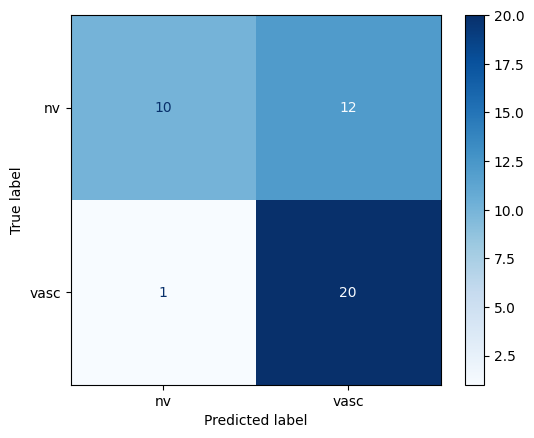

In [32]:
# Baseline training with Ray Joblib backend
train_pd = train_ds.to_pandas()
val_pd = val_ds.to_pandas()
test_pd = test_ds.to_pandas()

X_train = train_pd[FEATURE_COLUMNS].values
y_train = train_pd["label"].values
X_val = val_pd[FEATURE_COLUMNS].values
y_val = val_pd["label"].values
X_test = test_pd[FEATURE_COLUMNS].values
y_test = test_pd["label"].values

scaler = SkStandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

with joblib.parallel_backend("ray"):
    start = time.time()
    model = SVC(kernel="rbf", class_weight="balanced")
    model.fit(X_train_s, y_train)
    train_pred = model.predict(X_train_s)
    val_pred = model.predict(X_val_s)
    test_pred = model.predict(X_test_s)
    elapsed = time.time() - start

baseline_model = model
baseline_scaler = scaler

print(f"Baseline train time (s): {elapsed:.2f}")
print("Train accuracy:", accuracy_score(y_train, train_pred))
print("Val accuracy:", accuracy_score(y_val, val_pred))
print("Test accuracy:", accuracy_score(y_test, test_pred))
print("Train F1 macro:", f1_score(y_train, train_pred, average="macro"))
print("Val F1 macro:", f1_score(y_val, val_pred, average="macro"))
print("Test F1 macro:", f1_score(y_test, test_pred, average="macro"))

print("Baseline report:")
print(classification_report(y_test, test_pred, target_names=label_names))

cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap="Blues")
plt.show()

## Ray Tune: hyperparameter search
We run a small Ray Tune search over SVM `C` and `gamma` values to improve macro F1.

In [33]:
# Prepare arrays for tuning
train_pd = train_ds.to_pandas()
val_pd = val_ds.to_pandas()

X_train = train_pd[FEATURE_COLUMNS].values
y_train = train_pd["label"].values
X_val = val_pd[FEATURE_COLUMNS].values
y_val = val_pd["label"].values

def train_svm_tune(config, X_train, y_train, X_val, y_val):
    scaler = SkStandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)
    model = SVC(
        C=config["C"],
        gamma=config["gamma"],
        kernel="rbf",
        class_weight="balanced",
    )
    model.fit(X_train_s, y_train)
    pred = model.predict(X_val_s)
    score = f1_score(y_val, pred, average="macro")
    tune.report({"f1_macro": score})

param_space = {
    "C": tune.loguniform(0.1, 10.0),
    "gamma": tune.loguniform(1e-3, 1e-1),
}

tuner = Tuner(
    tune.with_parameters(
        train_svm_tune,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
    ),
    param_space=param_space,
    tune_config=TuneConfig(num_samples=6, metric="f1_macro", mode="max"),
)

result_grid = tuner.fit()
best_result = result_grid.get_best_result()
best_config = best_result.config

print("Best config:", best_config)
print("Best val f1_macro:", best_result.metrics["f1_macro"])

2026-05-27 00:41:41,778	INFO tune.py:1001 -- Wrote the latest version of all result files and experiment state to '/home/wiktor/ray_results/train_svm_tune_2026-05-27_00-41-37' in 0.0080s.
2026-05-27 00:41:41,785	INFO tune.py:1033 -- Total run time: 3.85 seconds (3.83 seconds for the tuning loop).


Best config: {'C': 4.387775254196677, 'gamma': 0.015696176279161155}
Best val f1_macro: 0.5542825968357883


## Final evaluation with tuned model
We retrain with the best hyperparameters on train+validation and evaluate on the test split.

2026-05-27 00:41:41,832	INFO logging.py:416 -- Registered dataset logger for dataset dataset_10_1
2026-05-27 00:41:41,858	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_10_1 =======
2026-05-27 00:41:41,859	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-05-27 00:41:41,860	INFO logging_progress.py:227 -- Active & requested resources: 0/12 CPU, 0.0B/768.0MiB object store
2026-05-27 00:41:41,861	INFO logging_progress.py:192 -- =============================================
2026-05-27 00:41:41,875	INFO streaming_executor.py:294 -- ✔️  Dataset dataset_10_1 execution finished in 0.24 seconds


Tuned model report:
              precision    recall  f1-score   support

          nv       0.74      0.64      0.68        22
        vasc       0.67      0.76      0.71        21

    accuracy                           0.70        43
   macro avg       0.70      0.70      0.70        43
weighted avg       0.70      0.70      0.70        43



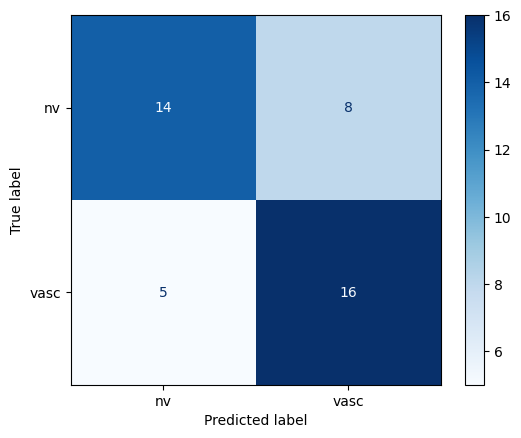

In [34]:
# Train final model with best config and evaluate
trainval_pd = pd.concat([train_pd, val_pd], ignore_index=True)
X_trainval = trainval_pd[FEATURE_COLUMNS].values
y_trainval = trainval_pd["label"].values

test_pd = test_ds.to_pandas()
X_test = test_pd[FEATURE_COLUMNS].values
y_test = test_pd["label"].values

scaler = SkStandardScaler()
X_trainval_s = scaler.fit_transform(X_trainval)
X_test_s = scaler.transform(X_test)

best_model = SVC(
    C=best_config["C"],
    gamma=best_config["gamma"],
    kernel="rbf",
    class_weight="balanced",
)
best_model.fit(X_trainval_s, y_trainval)
test_pred = best_model.predict(X_test_s)

print("Tuned model report:")
print(classification_report(y_test, test_pred, target_names=label_names))

cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap="Blues")
plt.show()

In [35]:
ray.shutdown()